In [1]:
%pip install geopandas

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\USER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

In [3]:
df = pd.read_csv('../../data/csv/physical_activities.csv')
indicators = df['IndicatorCode'].unique().tolist()
print(indicators)
df

['NCD_PAA', 'NCD_PAC', 'NCD_PAC_ADO']


,Unnamed: 0,ParentLocationCode,SpatialDim,Value,NumericValue,TimeDimensionBegin,TimeDimensionEnd,TimeDimensionValue,TimeDimType,TimeDim,IndicatorCode
0,0,WPR,BRN,26.7 [14.5-41.0],26.689821,2002-01-01T00:00:00+01:00,2002-12-31T00:00:00+01:00,2002,YEAR,2002,NCD_PAA
1,1,AMR,ATG,41.8 [15.4-72.3],41.846085,2016-01-01T00:00:00+01:00,2016-12-31T00:00:00+01:00,2016,YEAR,2016,NCD_PAA
2,2,WPR,NRU,44.6 [34.1-55.4],44.628899,2010-01-01T00:00:00+01:00,2010-12-31T00:00:00+01:00,2010,YEAR,2010,NCD_PAA
3,3,EUR,BLR,14.0 [9.3-19.8],14.017751,2022-01-01T00:00:00+01:00,2022-12-31T00:00:00+01:00,2022,YEAR,2022,NCD_PAA
4,4,EUR,PRT,56.4 [44.1-68.7],56.413315,2021-01-01T00:00:00+01:00,2021-12-31T00:00:00+01:00,2021,YEAR,2021,NCD_PAA
...,...,...,...,...,...,...,...,...,...,...,...
35518,35518,AFR,CAF,No data,NaN,2010-01-01T00:00:00+01:00,2010-12-31T00:00:00+01:00,2010,YEAR,2010,NCD_PAC_ADO
35519,35519,EUR,SVK,77.8 [74.3-81.0],77.809950,2012-01-01T00:00:00+01:00,2012-12-31T00:00:00+01:00,2012,YEAR,2012,NCD_PAC_ADO
35520,35520,AFR,ZWE,85.1 [82.4-87.4],85.069980,2002-01-01T00:00:00+01:00,2002-12-31T00:00:00+01:00,2002,YEAR,2002,NCD_PAC_ADO
35521,35521,AMR,BRA,78.9 [76.1-81.4],78.861730,2010-01-01T00:00:00+01:00,2010-12-31T00:00:00+01:00,2010,YEAR,2010,NCD_PAC_ADO


In [4]:
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

35523
35340
0


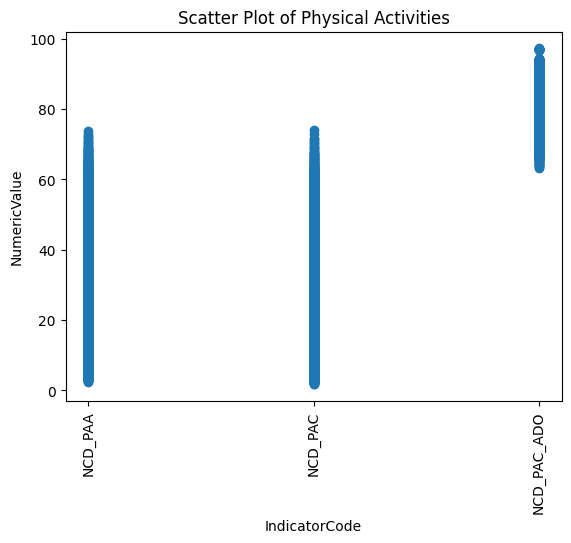

In [5]:
plt.figure()
plt.scatter(df['IndicatorCode'], df['NumericValue'])
plt.xlabel('IndicatorCode')
plt.ylabel('NumericValue')
plt.title('Scatter Plot of Physical Activities')
plt.xticks(rotation=90)
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_12616\1515023557.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=codes)


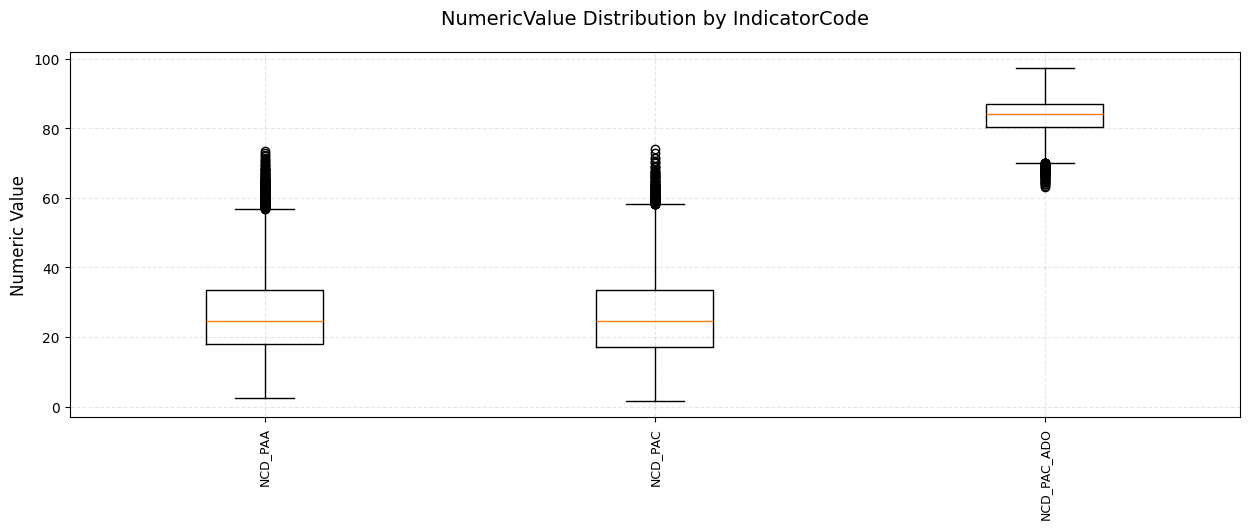

In [6]:
plt.figure(figsize=(14, 6))

codes = df['IndicatorCode'].unique()
data = [df[df['IndicatorCode'] == c]['NumericValue'] for c in codes]

plt.boxplot(data, labels=codes)
plt.xticks(rotation=90, fontsize=9)  # Xoay 90 độ và giảm font
plt.title('NumericValue Distribution by IndicatorCode', fontsize=14, pad=20)
plt.ylabel('Numeric Value', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

# Điều chỉnh layout để nhãn không bị cắt
plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.show()

Số lượng bản ghi Physical Activity: 14214
Khoảng thời gian: 1999-12-31 23:00:00+00:00 đến 2021-12-31 23:00:00+00:00
Số quốc gia/khu vực: 206

Thống kê MeanValue:
count    195.000000
mean      26.502386
std       10.627354
min        7.598633
25%       18.696191
50%       24.722331
75%       32.644117
max       61.824410
Name: MeanValue, dtype: float64

Số quốc gia/khu vực có dữ liệu sau khi gộp: 195

Các cột trong bản đồ: ['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH'

C:\Users\USER\AppData\Local\Temp\ipykernel_12616\112715747.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["NumericValue"] = pd.to_numeric(df1["NumericValue"], errors="coerce")
C:\Users\USER\AppData\Local\Temp\ipykernel_12616\112715747.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Date"] = pd.to_datetime(df1["TimeDimensionBegin"], errors="coerce", utc=True)


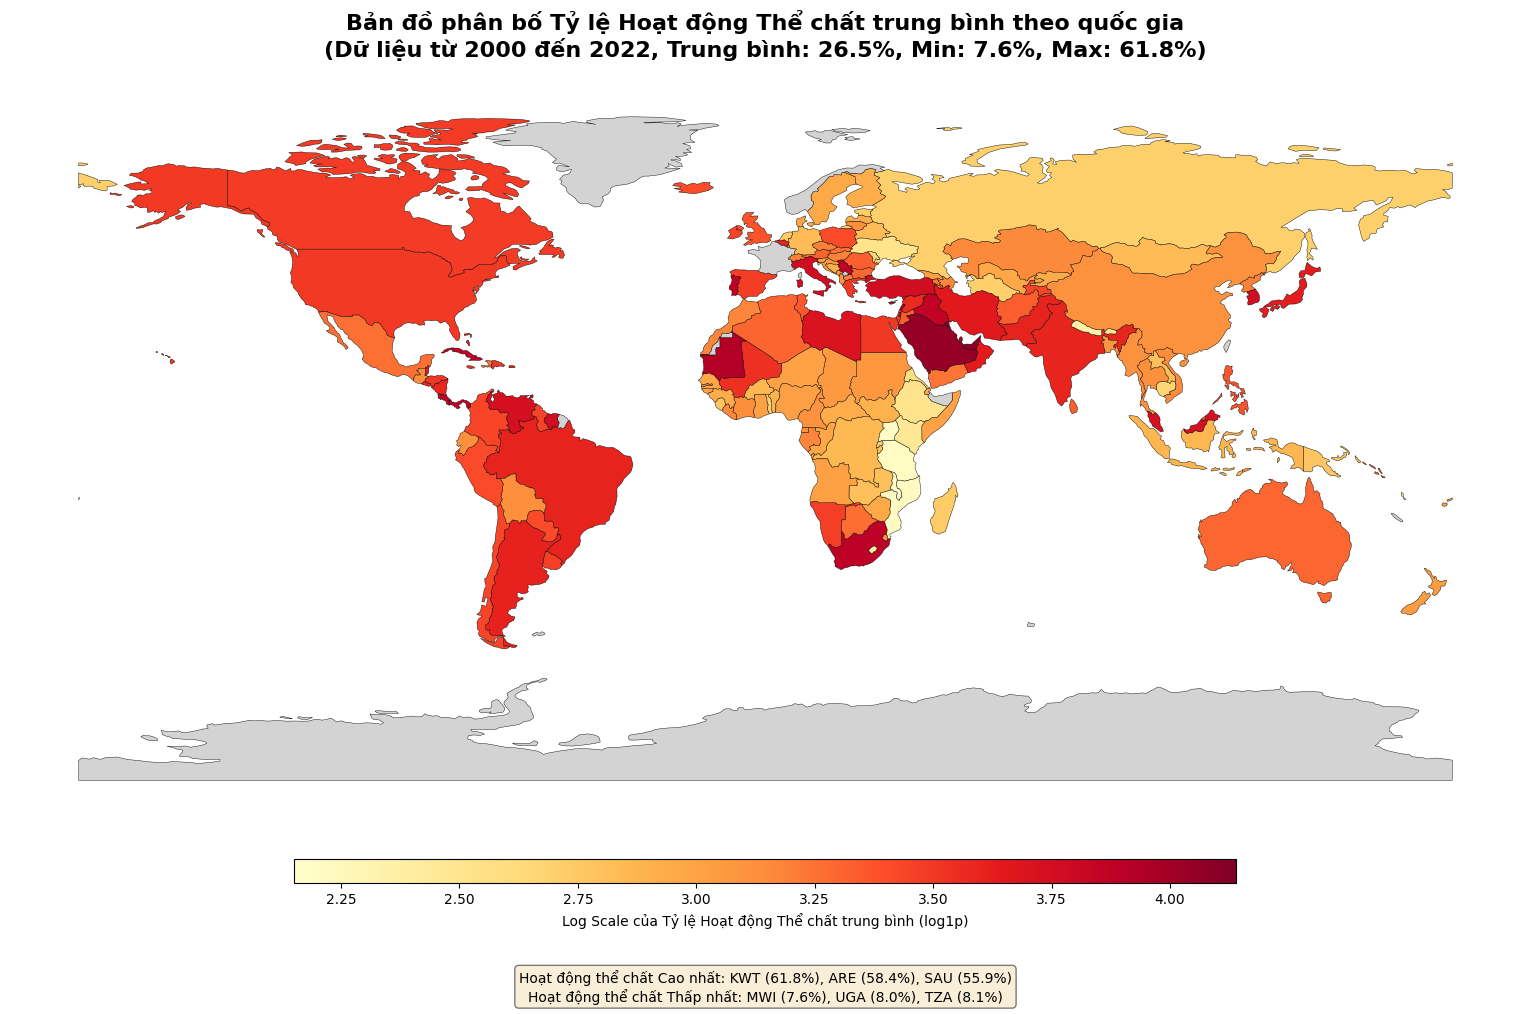

In [8]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# ==============================
# 1. KIỂM TRA & CHUẨN HÓA DỮ LIỆU PHYSICAL ACTIVITY
# ==============================
# Lọc dữ liệu cho chỉ số Physical Activity (NCD_PAA)
df1 = df[df['IndicatorCode'] == 'NCD_PAA']

# Chuyển đổi giá trị số
df1["NumericValue"] = pd.to_numeric(df1["NumericValue"], errors="coerce")

# Xử lý cột thời gian - dữ liệu có TimeDimensionBegin
# Chuyển đổi thành datetime với UTC
df1["Date"] = pd.to_datetime(df1["TimeDimensionBegin"], errors="coerce", utc=True)

# Kiểm tra dữ liệu
print(f"Số lượng bản ghi Physical Activity: {len(df1)}")
print(f"Khoảng thời gian: {df1['Date'].min()} đến {df1['Date'].max()}")
print(f"Số quốc gia/khu vực: {df1['SpatialDim'].nunique()}")

# ==============================
# 2. GỘP DỮ LIỆU & TÍNH LOG
# ==============================
# Nhóm dữ liệu theo quốc gia và tính trung bình
df_grouped = (
    df1.groupby(
        ["SpatialDim", "ParentLocationCode"],
        as_index=False
    )
    .agg(
        MeanValue=("NumericValue", "mean"),
        Count=("NumericValue", "count"),
        # Có thể thêm các thống kê khác nếu cần
        MinValue=("NumericValue", "min"),
        MaxValue=("NumericValue", "max"),
        StdValue=("NumericValue", "std")
    )
)

# Kiểm tra phân bố dữ liệu
print("\nThống kê MeanValue:")
print(df_grouped["MeanValue"].describe())

# Tạo cột LogMeanValue: log1p(x) = log(1 + x)
df_grouped["LogMeanValue"] = np.log1p(df_grouped["MeanValue"])

print(f"\nSố quốc gia/khu vực có dữ liệu sau khi gộp: {len(df_grouped)}")

# ==============================
# 3. LOAD BẢN ĐỒ & MERGE
# ==============================
# Lưu ý: Đảm bảo file bản đồ đúng đường dẫn
world = gpd.read_file("../../worldmap/ne_110m_admin_0_countries.shp")

# Kiểm tra cột mã quốc gia trong bản đồ
print("\nCác cột trong bản đồ:", world.columns.tolist())

# Merge dữ liệu Physical Activity với bản đồ
# SpatialDim trong dữ liệu của bạn là mã quốc gia 3 ký tự (ISO_A3)
gdf = world.merge(
    df_grouped,
    how="left",
    left_on="ISO_A3",  # Đảm bảo đúng tên cột trong shapefile
    right_on="SpatialDim"
)

# Kiểm tra kết quả merge
print(f"Số quốc gia trong bản đồ: {len(world)}")
print(f"Số quốc gia sau merge: {len(gdf)}")
print(f"Số quốc gia có dữ liệu Physical Activity: {gdf['MeanValue'].notna().sum()}")

# ==============================
# 4. VẼ BẢN ĐỒ VỚI THANG LOG
# ==============================
fig, ax = plt.subplots(figsize=(16, 10))

# Tạo colormap - GIỮ NGUYÊN NHƯ CŨ
cmap = plt.cm.YlOrRd  # Giữ nguyên YlOrRd như mã gốc

# Vẽ bản đồ với màu sắc dựa trên LogMeanValue
gdf.plot(
    column="LogMeanValue", 
    ax=ax,
    legend=True,
    cmap=cmap,
    edgecolor="black",
    linewidth=0.3,
    legend_kwds={
        'label': "Log Scale của Tỷ lệ Hoạt động Thể chất trung bình (log1p)",
        'orientation': "horizontal",
        'pad': 0.05,
        'shrink': 0.6,
        'aspect': 40
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "Không có dữ liệu",
        "edgecolor": "black",
        "linewidth": 0.3
    }
)

# Thêm thông tin thống kê vào title
avg_value = df_grouped["MeanValue"].mean()
min_value = df_grouped["MeanValue"].min()
max_value = df_grouped["MeanValue"].max()

title = (
    f"Bản đồ phân bố Tỷ lệ Hoạt động Thể chất trung bình theo quốc gia\n"
    f"(Dữ liệu từ {df1['TimeDimensionValue'].min()} đến {df1['TimeDimensionValue'].max()}, "
    f"Trung bình: {avg_value:.1f}%, Min: {min_value:.1f}%, Max: {max_value:.1f}%)"
)

ax.set_title(title, fontsize=16, pad=20, fontweight='bold')

# Thêm annotation cho các quốc gia có giá trị cao/thấp nhất
# Tìm 3 quốc gia có Physical Activity cao nhất và thấp nhất
top_3 = df_grouped.nlargest(3, 'MeanValue')
bottom_3 = df_grouped.nsmallest(3, 'MeanValue')

# Thêm text thông tin
info_text = (
    f"Hoạt động thể chất Cao nhất: {top_3.iloc[0]['SpatialDim']} ({top_3.iloc[0]['MeanValue']:.1f}%), "
    f"{top_3.iloc[1]['SpatialDim']} ({top_3.iloc[1]['MeanValue']:.1f}%), "
    f"{top_3.iloc[2]['SpatialDim']} ({top_3.iloc[2]['MeanValue']:.1f}%)\n"
    f"Hoạt động thể chất Thấp nhất: {bottom_3.iloc[0]['SpatialDim']} ({bottom_3.iloc[0]['MeanValue']:.1f}%), "
    f"{bottom_3.iloc[1]['SpatialDim']} ({bottom_3.iloc[1]['MeanValue']:.1f}%), "
    f"{bottom_3.iloc[2]['SpatialDim']} ({bottom_3.iloc[2]['MeanValue']:.1f}%)"
)

plt.figtext(0.5, 0.01, info_text, ha='center', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.axis("off")
plt.tight_layout()
plt.show()